In [ ]:
# --- предложенный boundary ---
# 1) нулевой луч вперёд по времени:   positions[0, k],   k=0..n_tau-1
# 2) граница достижимости по k:        positions[k, n_tau-1], k=1..n_tau
# 3) последний луч в обратном порядке (без крайней точки — уже есть в п.2)
boundary_new = np.concatenate([
    positions[0, :],              # k=0 ray forward: n_tau точек
    positions[1:, n_tau - 1],     # endpoints k=1..n_tau: n_tau точек
    positions[-1, -2::-1],        # k=n_tau reversed без endpoint: n_tau-1 точек
])
print('Предложенный boundary:')
print(f'  positions[0,:]          = {n_tau} точек  (k=0 ray вперёд)')
print(f'  positions[1:,n_tau-1]   = {n_tau} точек  (endpoints k=1..{n_tau})')
print(f'  positions[-1,-2::-1]    = {n_tau-1} точек (k={n_tau} reversed, без endpoint)')
print(f'  Итого: {len(boundary_new)} точек + 1 центр = {len(boundary_new)+1} вершин')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, (b, title, col) in zip(axes, [
    (boundary_current, 'Текущий', 'cyan'),
    (boundary_new,     'Предложенный', 'orange'),
]):
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('v')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

    for ray in range(n_tau + 1):
        pts = np.vstack([root, positions[ray]])
        ax.plot(pts[:, 0], pts[:, 1], color='gray', lw=1, alpha=0.3)

    poly = np.vstack([root, b, root])
    ax.fill(poly[:, 0], poly[:, 1], alpha=0.25, color=col)
    ax.plot(poly[:, 0], poly[:, 1], color=col, lw=2)

    for i, (bx, bv) in enumerate(b):
        ax.scatter(bx, bv, color=col, s=60, zorder=5)
        ax.annotate(str(i), (bx, bv), textcoords='offset points',
                    xytext=(4, 3), fontsize=8, color=col)

    ax.scatter(*root, color='white', s=120, zorder=10, edgecolors='black')
    ax.annotate('root', root, textcoords='offset points', xytext=(5, 5), fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- параметры ---
n_tau  = 4
tau    = 1.0
a_max  = 1.0
x0, v0 = 0.0, 0.5   # root

# template: branch_plus = ((+1,+1),(-1,+1))
u1_sign, t1_sign = +1, +1
u2_sign, t2_sign = -1, +1
u1 = u1_sign * a_max
u2 = u2_sign * a_max
dtau = tau / n_tau
dt1  = dtau * t1_sign
dt2  = dtau * t2_sign

# --- вычислить positions[ray, step, xv] ---
# ray k: шаги 1..k используют u1, шаги k+1..n_tau используют u2
x = np.full(n_tau + 1, x0)
v = np.full(n_tau + 1, v0)
k_arr = np.arange(0, n_tau + 1)

positions = np.zeros((n_tau + 1, n_tau, 2))  # [ray, step, xv]

for step_i in range(1, n_tau + 1):
    mask = step_i <= k_arr
    u  = np.where(mask, u1, u2)
    dt = np.where(mask, dt1, dt2)
    x = x + v * dt + 0.5 * u * dt * dt
    v = v + u * dt
    positions[:, step_i - 1, 0] = x
    positions[:, step_i - 1, 1] = v

root = np.array([x0, v0])
print(f'positions shape: {positions.shape}')  # (n_tau+1, n_tau, 2)
print(f'root: {root}')

positions shape: (5, 4, 2)
root: [0.  0.5]


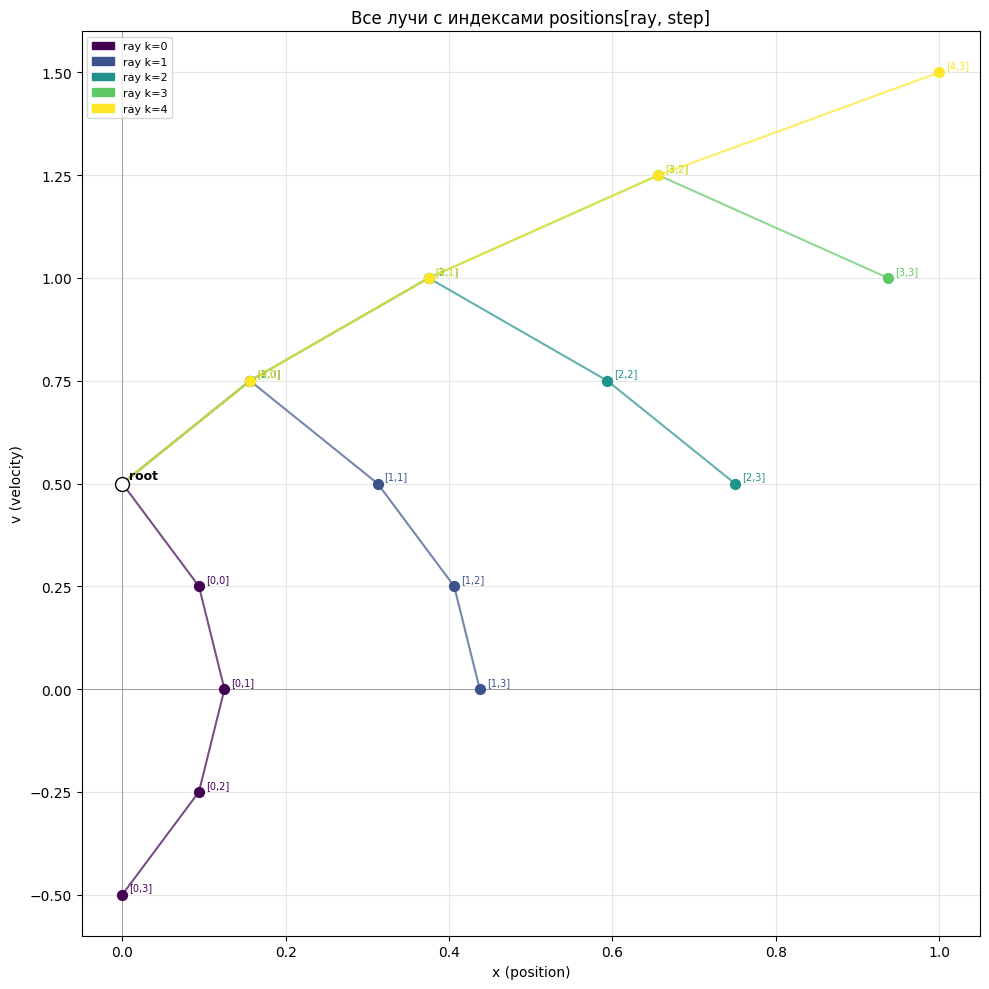

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('Все лучи с индексами positions[ray, step]')
ax.set_xlabel('x (position)')
ax.set_ylabel('v (velocity)')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

colors = plt.cm.viridis(np.linspace(0, 1, n_tau + 1))

for ray in range(n_tau + 1):
    pts = np.vstack([root, positions[ray]])  # (n_tau+1, 2): root + n_tau steps
    ax.plot(pts[:, 0], pts[:, 1], color=colors[ray], lw=1.5, alpha=0.7)
    # нанести индексы спор
    for step in range(n_tau):
        px, pv = positions[ray, step]
        ax.scatter(px, pv, color=colors[ray], s=50, zorder=5)
        ax.annotate(f'[{ray},{step}]', (px, pv),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=7, color=colors[ray])

# root
ax.scatter(*root, color='white', s=100, zorder=10, edgecolors='black')
ax.annotate('root', root, textcoords='offset points', xytext=(5, 3), fontsize=9, fontweight='bold')

# легенда лучей
patches = [mpatches.Patch(color=colors[k], label=f'ray k={k}') for k in range(n_tau+1)]
ax.legend(handles=patches, loc='upper left', fontsize=8)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Текущий boundary:
  positions[0,:]        = 4 точек  (k=0, шаги 0..3)
  positions[1:-1,-1]    = 3 точек (endpoints k=1..3)
  positions[-1,::-1]    = 4 точек  (k=4 reversed)
  Итого: 11 точек + 1 центр = 12 вершин


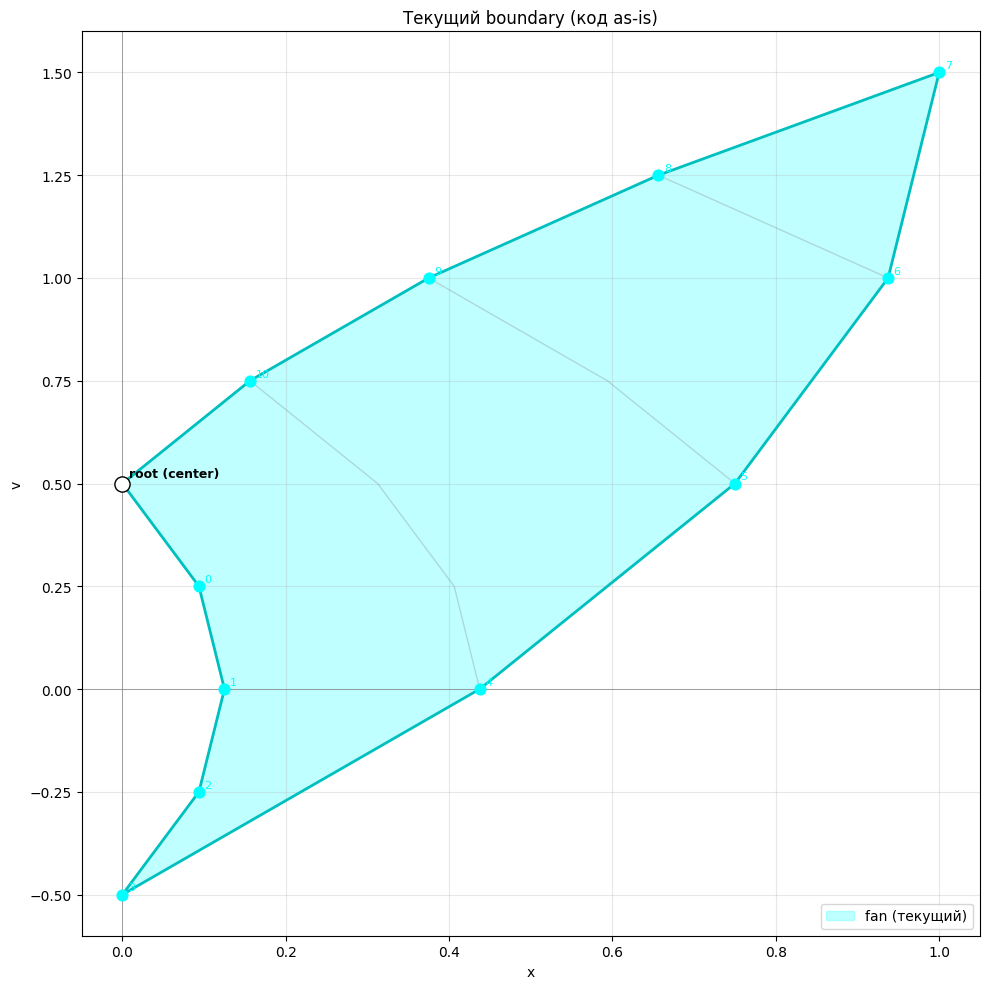

In [4]:
# --- текущий boundary из кода ---
boundary_current = np.concatenate([
    positions[0, :],          # k=0 ray: n_tau pts
    positions[1:-1, -1],      # inner envelope: n_tau-1 pts
    positions[-1, ::-1],      # k=n_tau ray reversed: n_tau pts
])
print('Текущий boundary:')
print(f'  positions[0,:]        = {n_tau} точек  (k=0, шаги 0..{n_tau-1})')
print(f'  positions[1:-1,-1]    = {n_tau-1} точек (endpoints k=1..{n_tau-1})')
print(f'  positions[-1,::-1]    = {n_tau} точек  (k={n_tau} reversed)')
print(f'  Итого: {len(boundary_current)} точек + 1 центр = {len(boundary_current)+1} вершин')

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('Текущий boundary (код as-is)')
ax.set_xlabel('x'); ax.set_ylabel('v')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

# все лучи фоном
for ray in range(n_tau + 1):
    pts = np.vstack([root, positions[ray]])
    ax.plot(pts[:, 0], pts[:, 1], color='gray', lw=1, alpha=0.3)

# boundary как полигон
poly = np.vstack([root, boundary_current, root])
ax.fill(poly[:, 0], poly[:, 1], alpha=0.25, color='cyan', label='fan (текущий)')
ax.plot(poly[:, 0], poly[:, 1], 'c-', lw=2)

# подписи точек boundary
for i, (bx, bv) in enumerate(boundary_current):
    ax.scatter(bx, bv, color='cyan', s=60, zorder=5)
    ax.annotate(str(i), (bx, bv), textcoords='offset points', xytext=(4, 3), fontsize=8, color='cyan')

ax.scatter(*root, color='white', s=120, zorder=10, edgecolors='black')
ax.annotate('root (center)', root, textcoords='offset points', xytext=(5, 5), fontsize=9, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Предложенный boundary:
  positions[0,:]          = 4 точек  (k=0 ray вперёд)
  positions[1:,n_tau-1]   = 4 точек  (endpoints k=1..4)
  positions[-1,-2::-1]    = 3 точек (k=4 reversed, без endpoint)
  Итого: 11 точек + 1 центр = 12 вершин


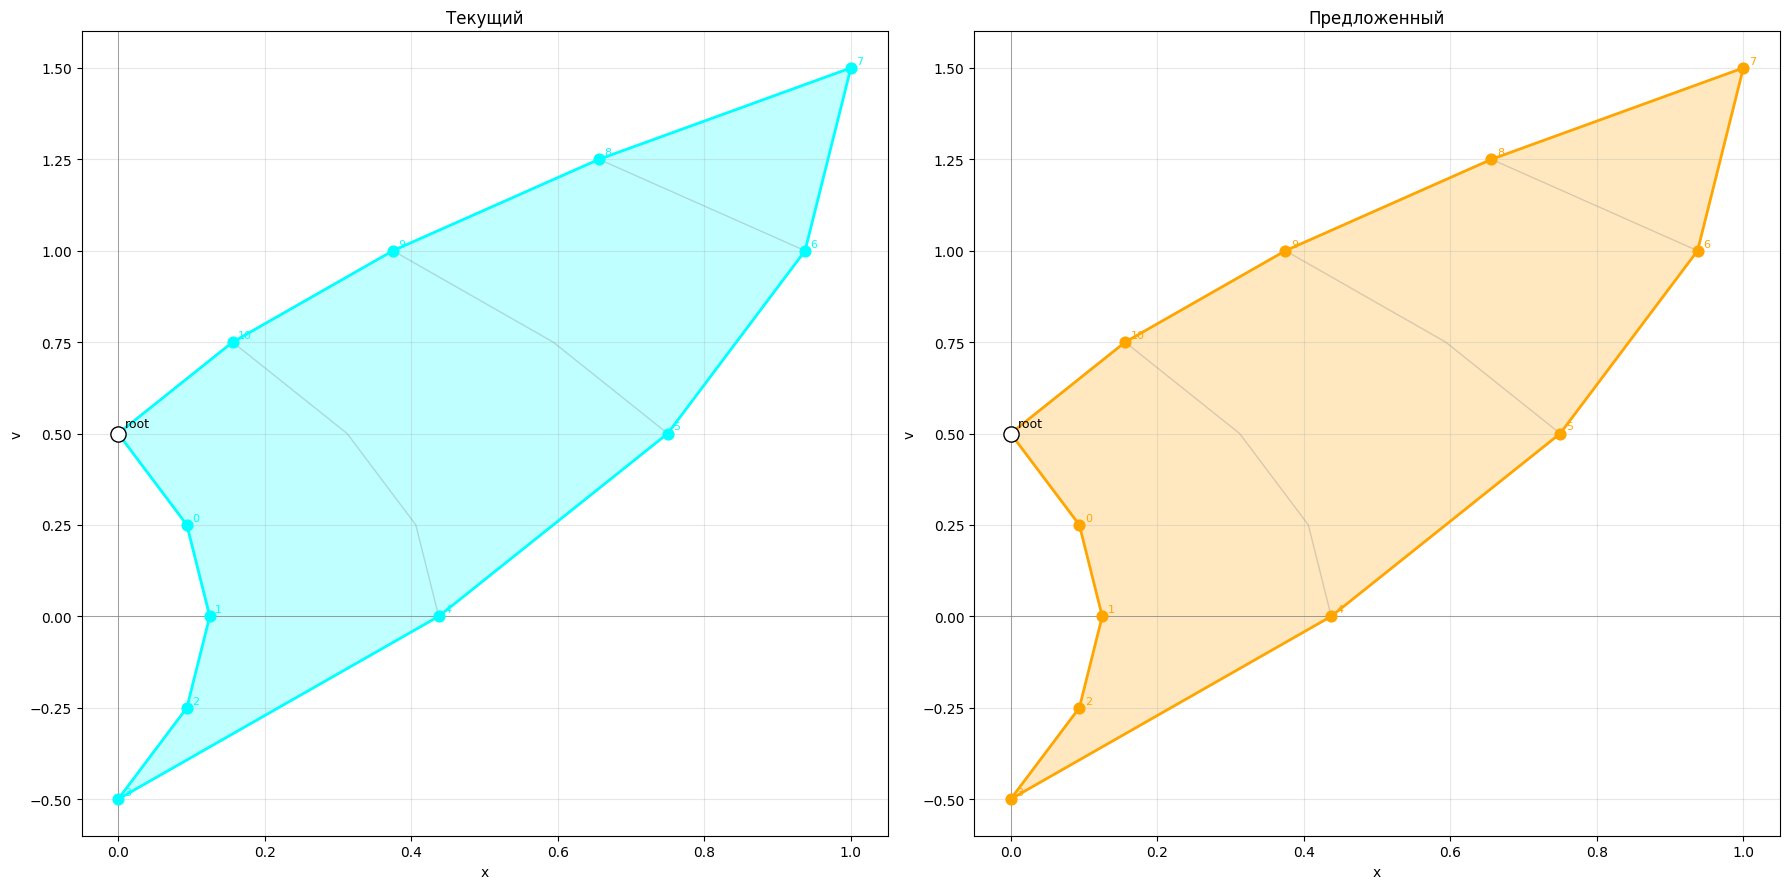

In [5]:
# --- предложенный boundary ---
# 1) нулевой луч вперёд по времени:   positions[0, k],   k=0..n_tau-1
# 2) граница достижимости по k:        positions[k, n_tau-1], k=1..n_tau
# 3) последний луч в обратном порядке (без крайней точки — уже есть в п.2)
boundary_new = np.concatenate([
    positions[0, :],              # k=0 ray forward: n_tau точек
    positions[1:, n_tau - 1],     # endpoints k=1..n_tau: n_tau точек
    positions[-1, -2::-1],        # k=n_tau reversed без endpoint: n_tau-1 точек
])
print('Предложенный boundary:')
print(f'  positions[0,:]          = {n_tau} точек  (k=0 ray вперёд)')
print(f'  positions[1:,n_tau-1]   = {n_tau} точек  (endpoints k=1..{n_tau})')
print(f'  positions[-1,-2::-1]    = {n_tau-1} точек (k={n_tau} reversed, без endpoint)')
print(f'  Итого: {len(boundary_new)} точек + 1 центр = {len(boundary_new)+1} вершин')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, (b, title, col) in zip(axes, [
    (boundary_current, 'Текущий', 'cyan'),
    (boundary_new,     'Предложенный', 'orange'),
]):
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('v')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

    for ray in range(n_tau + 1):
        pts = np.vstack([root, positions[ray]])
        ax.plot(pts[:, 0], pts[:, 1], color='gray', lw=1, alpha=0.3)

    poly = np.vstack([root, b, root])
    ax.fill(poly[:, 0], poly[:, 1], alpha=0.25, color=col)
    ax.plot(poly[:, 0], poly[:, 1], color=col, lw=2)

    for i, (bx, bv) in enumerate(b):
        ax.scatter(bx, bv, color=col, s=60, zorder=5)
        ax.annotate(str(i), (bx, bv), textcoords='offset points',
                    xytext=(4, 3), fontsize=8, color=col)

    ax.scatter(*root, color='white', s=120, zorder=10, edgecolors='black')
    ax.annotate('root', root, textcoords='offset points', xytext=(5, 5), fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()